In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

## Задание 1. Загрузка изображения в оттенках серого

Форма изображения: (400, 600) | тип данных: uint8
Мин. яркость: 0 | макс. яркость: 255 | средняя яркость: 74.94


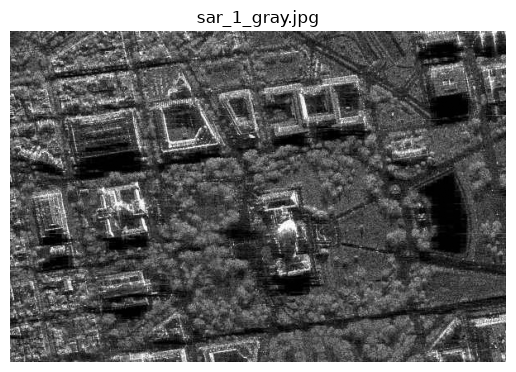

In [2]:
image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

print('Форма изображения:', image_gray.shape, '| тип данных:', image_gray.dtype)
print('Мин. яркость:', image_gray.min(), '| макс. яркость:', image_gray.max(),
      '| средняя яркость:', round(image_gray.mean(), 2))

plt.imshow(image_gray, cmap='gray')
plt.title('sar_1_gray.jpg')
plt.axis('off')
plt.show()

## Задание 2. Построение гистограммы

In [3]:
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)

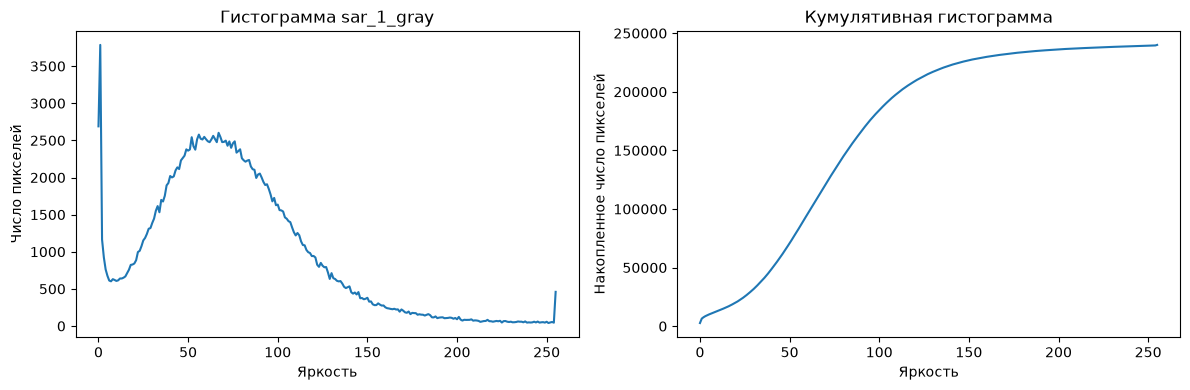

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(gray_hist)
plt.title('Гистограмма sar_1_gray')
plt.xlabel('Яркость')
plt.ylabel('Число пикселей')

plt.subplot(1, 2, 2)
plt.plot(gray_hist.cumsum())
plt.title('Кумулятивная гистограмма')
plt.xlabel('Яркость')
plt.ylabel('Накопленное число пикселей')

plt.tight_layout()

## Задание 3. Гамма-коррекция (собственная реализация)

Степенное преобразование: $s = c \cdot r^{\gamma}$. При **гамма < 1** изображение становится светлее,
при **гамма > 1** - темнее.

In [5]:
def gamma_correction(img, gamma=1.0):
    # таблица соответствия LUT: новое значение = (старое / 255) ** gamma * 255
    table = ((np.arange(256, dtype=np.float32) / 255.0) ** gamma * 255.0).astype(np.uint8)
    return cv2.LUT(img, table)

img_gamma_low = gamma_correction(image_gray, gamma=0.5)   # гамма < 1
img_gamma_high = gamma_correction(image_gray, gamma=2.0)  # гамма > 1

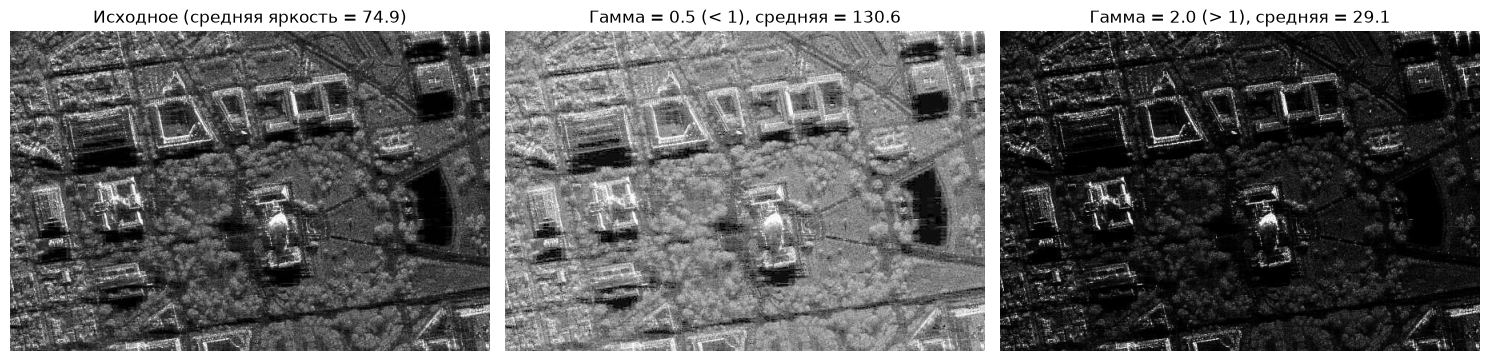

In [6]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное (средняя яркость = %.1f)' % image_gray.mean())
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_low, cmap='gray')
plt.title('Гамма = 0.5 (< 1), средняя = %.1f' % img_gamma_low.mean())
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_gamma_high, cmap='gray')
plt.title('Гамма = 2.0 (> 1), средняя = %.1f' % img_gamma_high.mean())
plt.axis('off')

plt.tight_layout()

## Задание 4. Сравнение исходного и гамма-корректированного изображений (MSE, SSIM)

In [7]:
from skimage.metrics import structural_similarity, mean_squared_error

for name, res in [('Гамма = 0.5 (< 1)', img_gamma_low),
                  ('Гамма = 2.0 (> 1)', img_gamma_high)]:
    mse = mean_squared_error(image_gray, res)
    ssim = structural_similarity(image_gray, res)
    print('%s: MSE = %.2f, SSIM = %.4f' % (name, mse, ssim))

Гамма = 0.5 (< 1): MSE = 3250.43, SSIM = 0.7875
Гамма = 2.0 (> 1): MSE = 2383.76, SSIM = 0.5270


## Задание 5. Статистическая цветокоррекция на основе статистики eq_gray

**Эквализация гистограммы - собственная реализация** (стандартная формула через кумулятивную
гистограмму): $h(v) = \mathrm{round}\!\left(\dfrac{cdf(v) - cdf_{min}}{N - cdf_{min}} \cdot 255\right)$.

In [8]:
def hist_equalize(img):
    # собственная реализация эквализации гистограммы
    hist = cv2.calcHist([img], [0], None, [256], (0, 256)).flatten()
    cdf = hist.cumsum()
    cdf_min = cdf[np.nonzero(cdf)[0][0]]
    lut = np.round((cdf - cdf_min) / (img.size - cdf_min) * 255.0).clip(0, 255).astype(np.uint8)
    return lut[img]

eq_gray = hist_equalize(image_gray)

# проверка корректности собственной реализации
diff = np.abs(eq_gray.astype(int) - cv2.equalizeHist(image_gray).astype(int)).max()
print('Максимальное отличие от cv2.equalizeHist:', diff)
print('Статистики eq_gray: mean = %.2f, std = %.2f' % (eq_gray.mean(), eq_gray.std()))

Максимальное отличие от cv2.equalizeHist: 0
Статистики eq_gray: mean = 127.03, std = 74.27


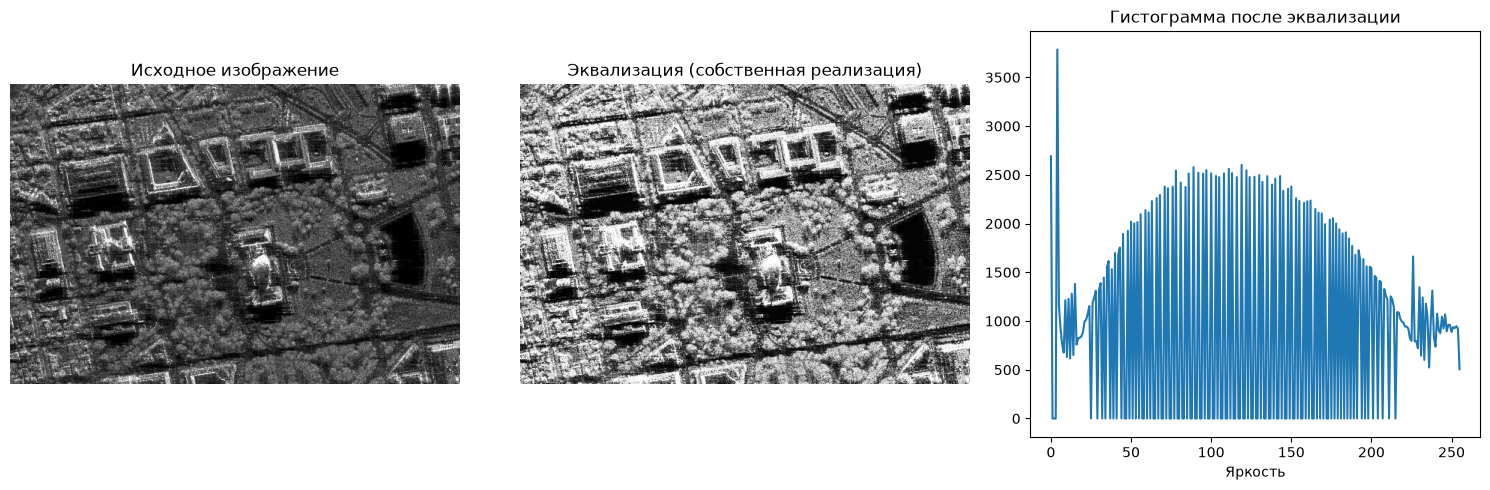

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Эквализация (собственная реализация)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(cv2.calcHist([eq_gray], [0], None, [256], (0, 256)))
plt.title('Гистограмма после эквализации')
plt.xlabel('Яркость')

plt.tight_layout()

**Статистическая цветокоррекция - собственная реализация.** Каналы изображения-источника
линейно преобразуются так, чтобы их среднее и СКО совпали со статистиками целевого
изображения (`eq_gray`):

$s = \dfrac{r - \mu_{src}}{\sigma_{src}} \cdot \sigma_{ref} + \mu_{ref}$

Цветное изображение `sar_2_color.jpg` переводится в модель **Lab**, и яркостный канал **L**
приводится к статистикам `eq_gray` (цветовые каналы a, b сохраняются).

In [10]:
image = cv2.imread('sar_2_color.jpg')

def stat_color_correction(src, mean_ref, std_ref):
    # собственная реализация статистической цветокоррекции:
    # статистики (mean, std) каждого канала источника приводятся к целевым
    corrected = np.empty_like(src)
    for c in range(src.shape[2]):
        ch = src[:, :, c].astype(np.float32)
        res = (ch - ch.mean()) / ch.std() * std_ref + mean_ref
        corrected[:, :, c] = np.clip(res, 0, 255)
    return corrected.astype(np.uint8)

# цветокоррекция цветного изображения в модели Lab: канал L -> статистики eq_gray
lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
lab_l, lab_a, lab_b = cv2.split(lab)

lab_l_corr = stat_color_correction(lab_l[..., None], eq_gray.mean(), eq_gray.std())[:, :, 0]
image_stat_corr = cv2.cvtColor(cv2.merge([lab_l_corr, lab_a, lab_b]), cv2.COLOR_Lab2BGR)

print('Канал L до коррекции:   mean = %.2f, std = %.2f' % (lab_l.mean(), lab_l.std()))
print('Канал L после коррекции: mean = %.2f, std = %.2f' % (lab_l_corr.mean(), lab_l_corr.std()))
print('Статистики eq_gray:      mean = %.2f, std = %.2f' % (eq_gray.mean(), eq_gray.std()))

Канал L до коррекции:   mean = 75.16, std = 58.96
Канал L после коррекции: mean = 124.82, std = 70.79
Статистики eq_gray:      mean = 127.03, std = 74.27


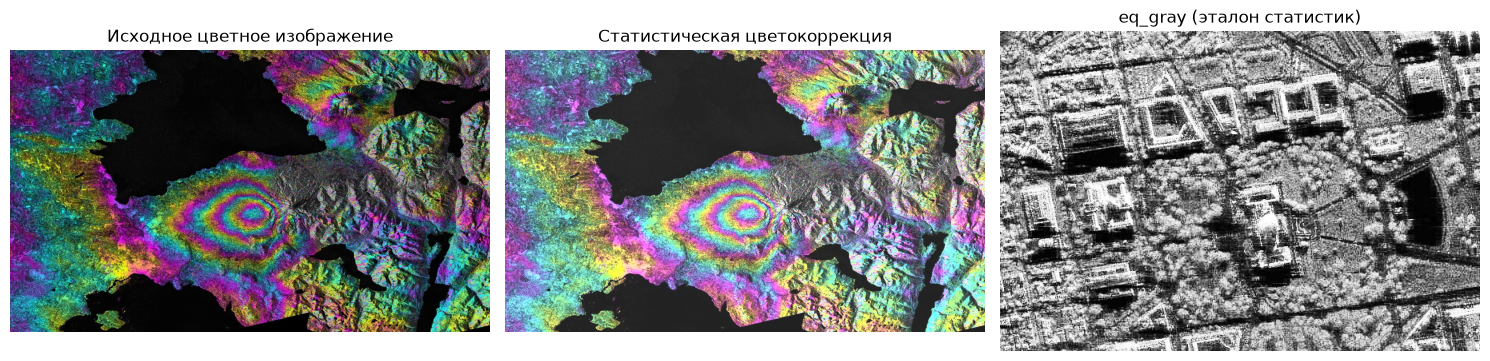

In [11]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Исходное цветное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(image_stat_corr, cv2.COLOR_BGR2RGB))
plt.title('Статистическая цветокоррекция')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(eq_gray, cmap='gray')
plt.title('eq_gray (эталон статистик)')
plt.axis('off')

plt.tight_layout()

## Задание 6. Пороговая фильтрация с различными параметрами

Глобальная фильтрация `cv2.threshold` с разными типами и порогами:

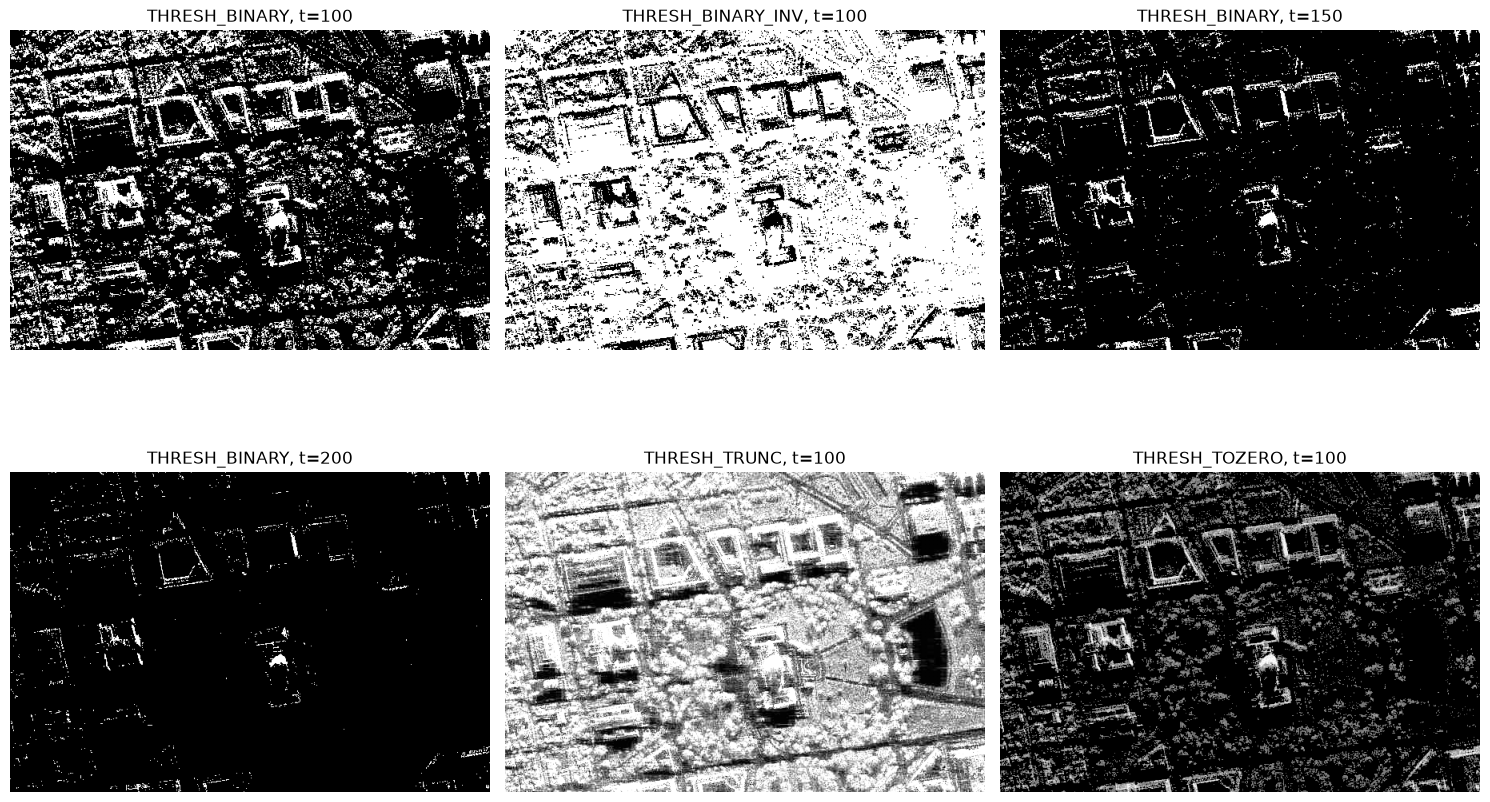

In [12]:
thresh_params = [
    (100, cv2.THRESH_BINARY,     'THRESH_BINARY, t=100'),
    (100, cv2.THRESH_BINARY_INV, 'THRESH_BINARY_INV, t=100'),
    (150, cv2.THRESH_BINARY,     'THRESH_BINARY, t=150'),
    (200, cv2.THRESH_BINARY,     'THRESH_BINARY, t=200'),
    (100, cv2.THRESH_TRUNC,      'THRESH_TRUNC, t=100'),
    (100, cv2.THRESH_TOZERO,     'THRESH_TOZERO, t=100'),
]

plt.figure(figsize=(15, 10))
for i, (t, mode, title) in enumerate(thresh_params, 1):
    _, res = cv2.threshold(image_gray, t, 255, mode)
    plt.subplot(2, 3, i)
    plt.imshow(res, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()

Автоматический выбор порога (метод Отсу) и адаптивная пороговая фильтрация:

Порог, выбранный методом Отсу: 85


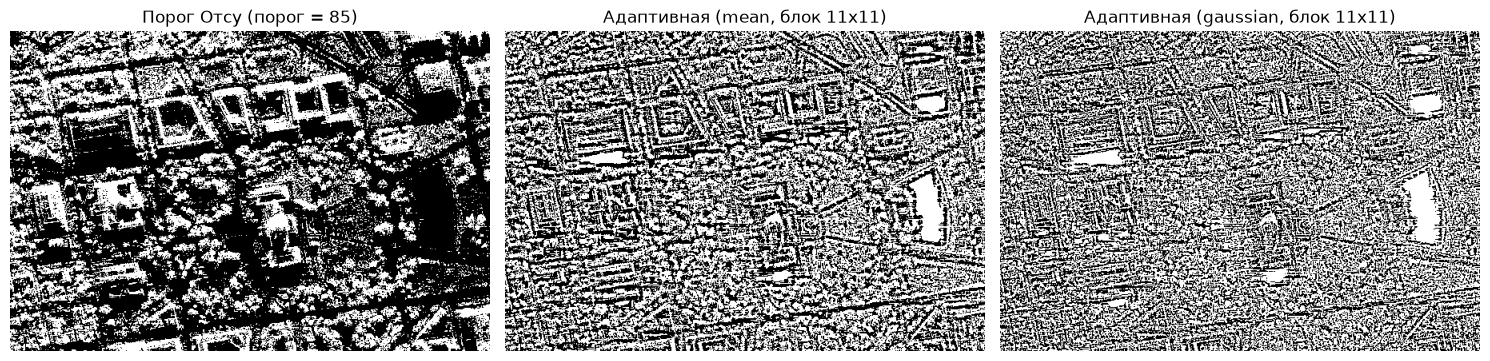

In [13]:
otsu_thresh, thresh_otsu = cv2.threshold(image_gray, 0, 255,
                                         cv2.THRESH_BINARY + cv2.THRESH_OTSU)
thresh_adapt_mean = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                          cv2.THRESH_BINARY, 11, 5)
thresh_adapt_gauss = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv2.THRESH_BINARY, 11, 5)

print('Порог, выбранный методом Отсу:', int(otsu_thresh))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresh_otsu, cmap='gray')
plt.title('Порог Отсу (порог = %d)' % int(otsu_thresh))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_adapt_mean, cmap='gray')
plt.title('Адаптивная (mean, блок 11x11)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_adapt_gauss, cmap='gray')
plt.title('Адаптивная (gaussian, блок 11x11)')
plt.axis('off')

plt.tight_layout()